### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from pathlib import Path
import sys
import os

In [2]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

### 1. Data

In [3]:
filepath = os.path.join(grandparent_dir,"Processed Data/preprocessed_data_final.csv")

In [4]:
df = pd.read_csv(filepath)
cols = ["Freq","VHr1","Modulation (RMS)","I1 Mag (A * 10^6)","I2 Mag (A * 10^6)","I3 Mag (A * 10^6)","Rank","File Number"]
df = df[cols]
df1 = df[(df["Rank"] == 6) & (df["File Number"] == 1)] #0.3 Hz, Run 1
df2 = df[(df["Rank"] == 6) & (df["File Number"] == 2)] #0.3 Hz, Run 2
df1

,Freq,VHr1,Modulation (RMS),I1 Mag (A * 10^6),I2 Mag (A * 10^6),I3 Mag (A * 10^6),Rank,File Number
5,0.300481,0.001414,1mV,1.269219,0.000810,0.001012,6,1
29,0.300481,0.007072,5mV,6.315401,0.028239,0.014147,6,1
53,0.300481,0.014143,10mV,12.411208,0.102224,0.123373,6,1
77,0.300481,0.028284,20mV,23.596565,0.348041,0.914223,6,1
101,0.300481,0.070711,50mV,45.009081,1.004144,7.968671,6,1
125,0.300481,0.141421,100mV,57.027241,0.908853,20.278651,6,1


### 2. Plots for 0.3 Hz (Run 1 and Run 2)

In [5]:
def plot_filled_pair(ax, df1, num_currents, point_pairs, run):
    '''
    Plots harmonic growth models based on the starting/ending index of the potential modulations
    to be included in the fit from the dataframe 
    (e.g. 1 mV to 5 mV)
    
    Args:
        df (pd.DataFrame): pandas Dataframe containing the current and voltages of the wanted harmonics
        num_currents (int): number of harmonic currents to be plotted up to, starting from the first harmonic
        points_pairs (tuple): the (start_index, end_index) indices corresponding to the modulations 
        which appear in the dataset when sorted from smallest to largest, starting from 1, to use in fit
        (e.g. 1 mV, 5 mV, 10 mV, ... with corresponding indices of 1, 2, 3)
        run (int): file number 1 or 2
        save (bool): if True, tight_layout + savefig + show (standalone use).
        Pass save=False when composing into a grid of subplots.
    
    Return:
        None
    '''
    
    # Set border widths
    for location in ['left', 'right', 'top', 'bottom']:
        ax.spines[location].set_linewidth(0.75)
    
    #Initialize Variables
    log_cols = [f"I{x} Mag (A * 10^6)" for x in range(1, num_currents + 1)]
    freq = df1["Freq"].iloc[0]
    f = 96485 / 8.314 / 298
    x_lim_min = 8e-4
    x_lim_max = 1.8e-1
    y_lim_min = 5e-10 * 1e6
    y_lim_max = 5e-4 * 1e6
    triangle_centers_pct = [0.25,0.735,0.45]  # list to store center x of each triangle
    triangle_width_log = 0.12  # width in log10(x) space
    colors = [
    '#318DD9', '#A8C9F4',  # first harmonic: original + pastel
    '#FAA628', '#FFE0A3',  # second harmonic: original + pastel
    '#A000C5', '#D9A3E6',  # third harmonic: original + pastel
    '#00C556', '#99E6B8',  # fourth harmonic: original + pastel
    ]

    # Compute the two-point best fits / Plot the Harmonic Models
    for i, col in enumerate(log_cols):
        slope = i + 1
        idx1, idx2 = point_pairs[i]
        idx1 -= 1  # convert to 0-based
        idx2 -= 1

        # Get x and y values of the two points for line fit
        x_fit = df1['VHr1'].iloc[[idx1, idx2]].values
        y_fit = df1[col].iloc[[idx1, idx2]].values

        # Compute best-fit intercept in log-log space
        X = np.log10(x_fit)
        Y = np.log10(y_fit)
        b = np.mean(Y - slope * X)

        # Generate line for plotting
        x_vals = np.linspace(x_lim_min, x_lim_max, 200)
        y_vals = 10**b * x_vals**slope

        # Color pair
        start = 2 * i
        end = 2 * i + 2
        pair = colors[start:end]
        
        # Plot fit line
        ax.plot(x_vals, y_vals, linestyle='-', color=pair[0], linewidth=0.75)
        
        #Plot Triangles
        pct = triangle_centers_pct[i]
        x_center = x_lim_min * (x_lim_max/x_lim_min)**pct  # log-scale interpolation
        log_center = np.log10(x_center)
        log_left = log_center - triangle_width_log/2
        log_right = log_center + triangle_width_log/2
        x_left = 10**log_left
        x_right = 10**log_right
        y_base = 10**b * x_left**slope
        y_top = 10**b * x_right**slope
        verts = [(x_left, y_base), (x_right, y_base), (x_right, y_top)]
        triangle = Polygon(verts, closed=True, facecolor=pair[1],edgecolor = pair[0], alpha=1,linewidth=0.75)
        ax.add_patch(triangle)

        #Plot the Triangle Slope Labels
        x_offset_log = -0.065  # shift right by 0.02 in log10(x)
        y_offset_log = -0.1  # shift down by 0.05 in log10(y)
        x_br = x_right
        y_br = y_base
        x_text = 10**(np.log10(x_br) + x_offset_log)
        y_text = 10**(np.log10(y_br) + y_offset_log)
        ax.text(x_text, y_text, f'$j = {slope}$',
                fontsize=7, color=colors[2*i], ha='left', va='top')

    # Plot Experimental Scatter points
    for i, col in enumerate(log_cols):
        start = 2 * i
        end = 2 * i + 2
        pair = colors[start:end]
        beg = 1
        end = 3
        if i == 0:
            beg = 0
            end = 2
        ax.scatter(df1["VHr1"].iloc[beg:end], df1[col].iloc[beg:end], color = pair[0], label=f'{col} File 1', zorder=5,s = 15,linewidth = 0.75,marker = "o")
        ax.scatter(df1["VHr1"].iloc[end:], df1[col].iloc[end:], edgecolor=pair[0], facecolors = 'none', label=f'{col} File 1', zorder=5,s = 15,linewidth = 0.75,marker = "o")

    # Axes settings
    ax.set_xlabel('$∆E$, Volts', fontsize=12)
    ax.set_ylabel(r'Current |$\tilde{\mathrm{I}}_{\mathrm{j},\!\mathrm{proc}}$|, $\mu$A',fontsize=12)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(x_lim_min, x_lim_max)
    ax.set_ylim(y_lim_min, y_lim_max)
    ax.tick_params(axis='both', which='major', labelsize=10, length=4.5, width=0.75, direction='in')
    ax.tick_params(axis='both', which='minor', length=2.5, width=0.6, direction='in')


    # Dotted Vertical line
    ax.axvline(x=1/f, color='black', linestyle='--', linewidth=0.75)
    ax.text(1/f, y_lim_min / 1.3, r'$f^{-1}$', fontsize=10, ha='center', va='top')

    # Text annotations |Ij|
    ax.text(0.18, 0.69, r'|$\tilde{\mathrm{I}}_{\mathrm{1}}$|', transform=ax.transAxes,
            fontsize=12, color=colors[0], va='center', ha='left')
    ax.text(0.1, 0.17, r'|$\tilde{\mathrm{I}}_{\mathrm{2}}$|', transform=ax.transAxes,
            fontsize=12, color=colors[2], va='center', ha='left')
    ax.text(0.3, 0.07, r'|$\tilde{\mathrm{I}}_{\mathrm{3}}$|', transform=ax.transAxes,
            fontsize=12, color=colors[4], va='center', ha='left')

    # Text labels for weakly/strongly nonlinear regions
    x = 1 / f
    mid_x_weakly = np.sqrt(x * x_lim_min)
    mid_x_strongly = np.sqrt(x * x_lim_max)
    ax.text(mid_x_weakly, 2.9e2, "Weakly Nonlinear",
            fontsize=6.25, color="black", va='center', ha='center', fontweight='medium',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#f0f0f0", edgecolor="black", linewidth=0.5, alpha=0.9))
    ax.text(mid_x_strongly, 2.9e2, "Strongly Nonlinear",
            fontsize=6.25, color="black", va='center', ha='center', fontweight='medium',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#ffe6cc", edgecolor="black", linewidth=0.5, alpha=0.9))

## Run 1

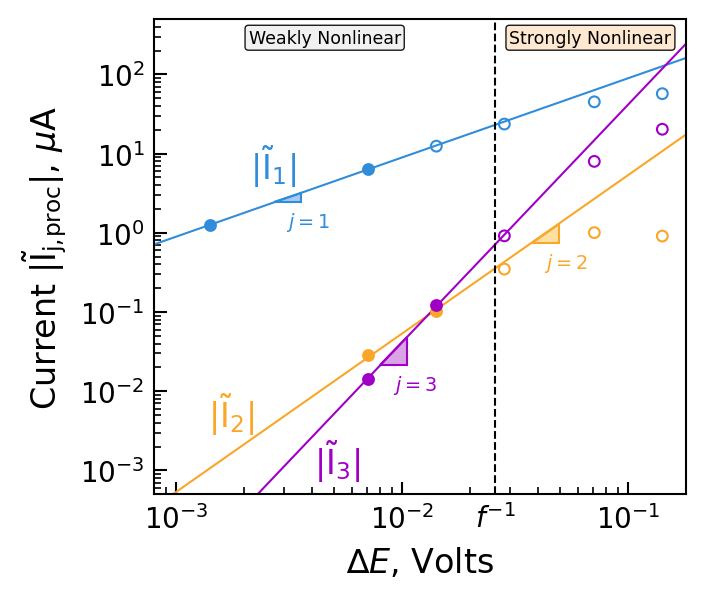

In [6]:
fig, ax = plt.subplots(figsize=(3.33, 2.8),dpi=200) #9,6.5
plot_filled_pair(ax,df1,3,[(1,2),(2,3),(2,3)],1)
plt.tight_layout(pad=0)
plt.savefig(f"Figure3_Harmonic_Growth_0.3004808_Hz_Run1.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()

## Run 2

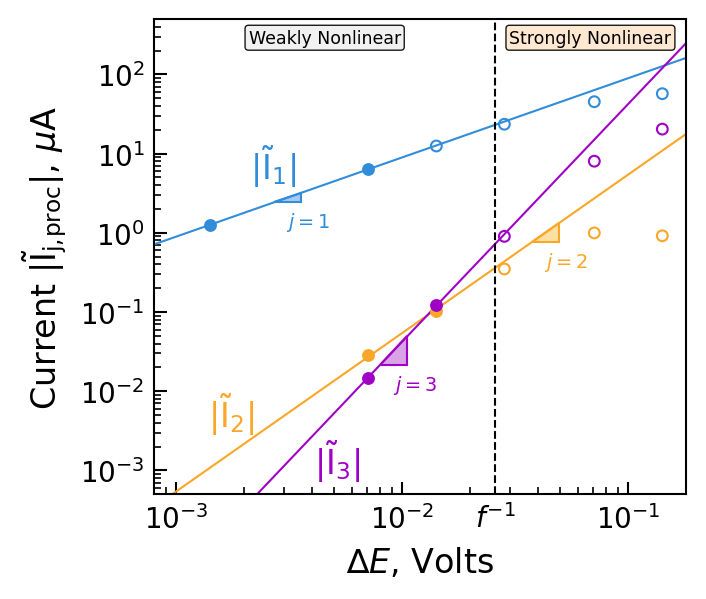

In [7]:
fig2, ax2 = plt.subplots(figsize=(3.33, 2.8),dpi=200) #9,6.5
plot_filled_pair(ax2, df2,3,[(1,2),(2,3),(2,3)],2)
plt.tight_layout(pad=0)
plt.show()

### 3. Grid Plots of All Frequencies (Supporting Information)

Run 1


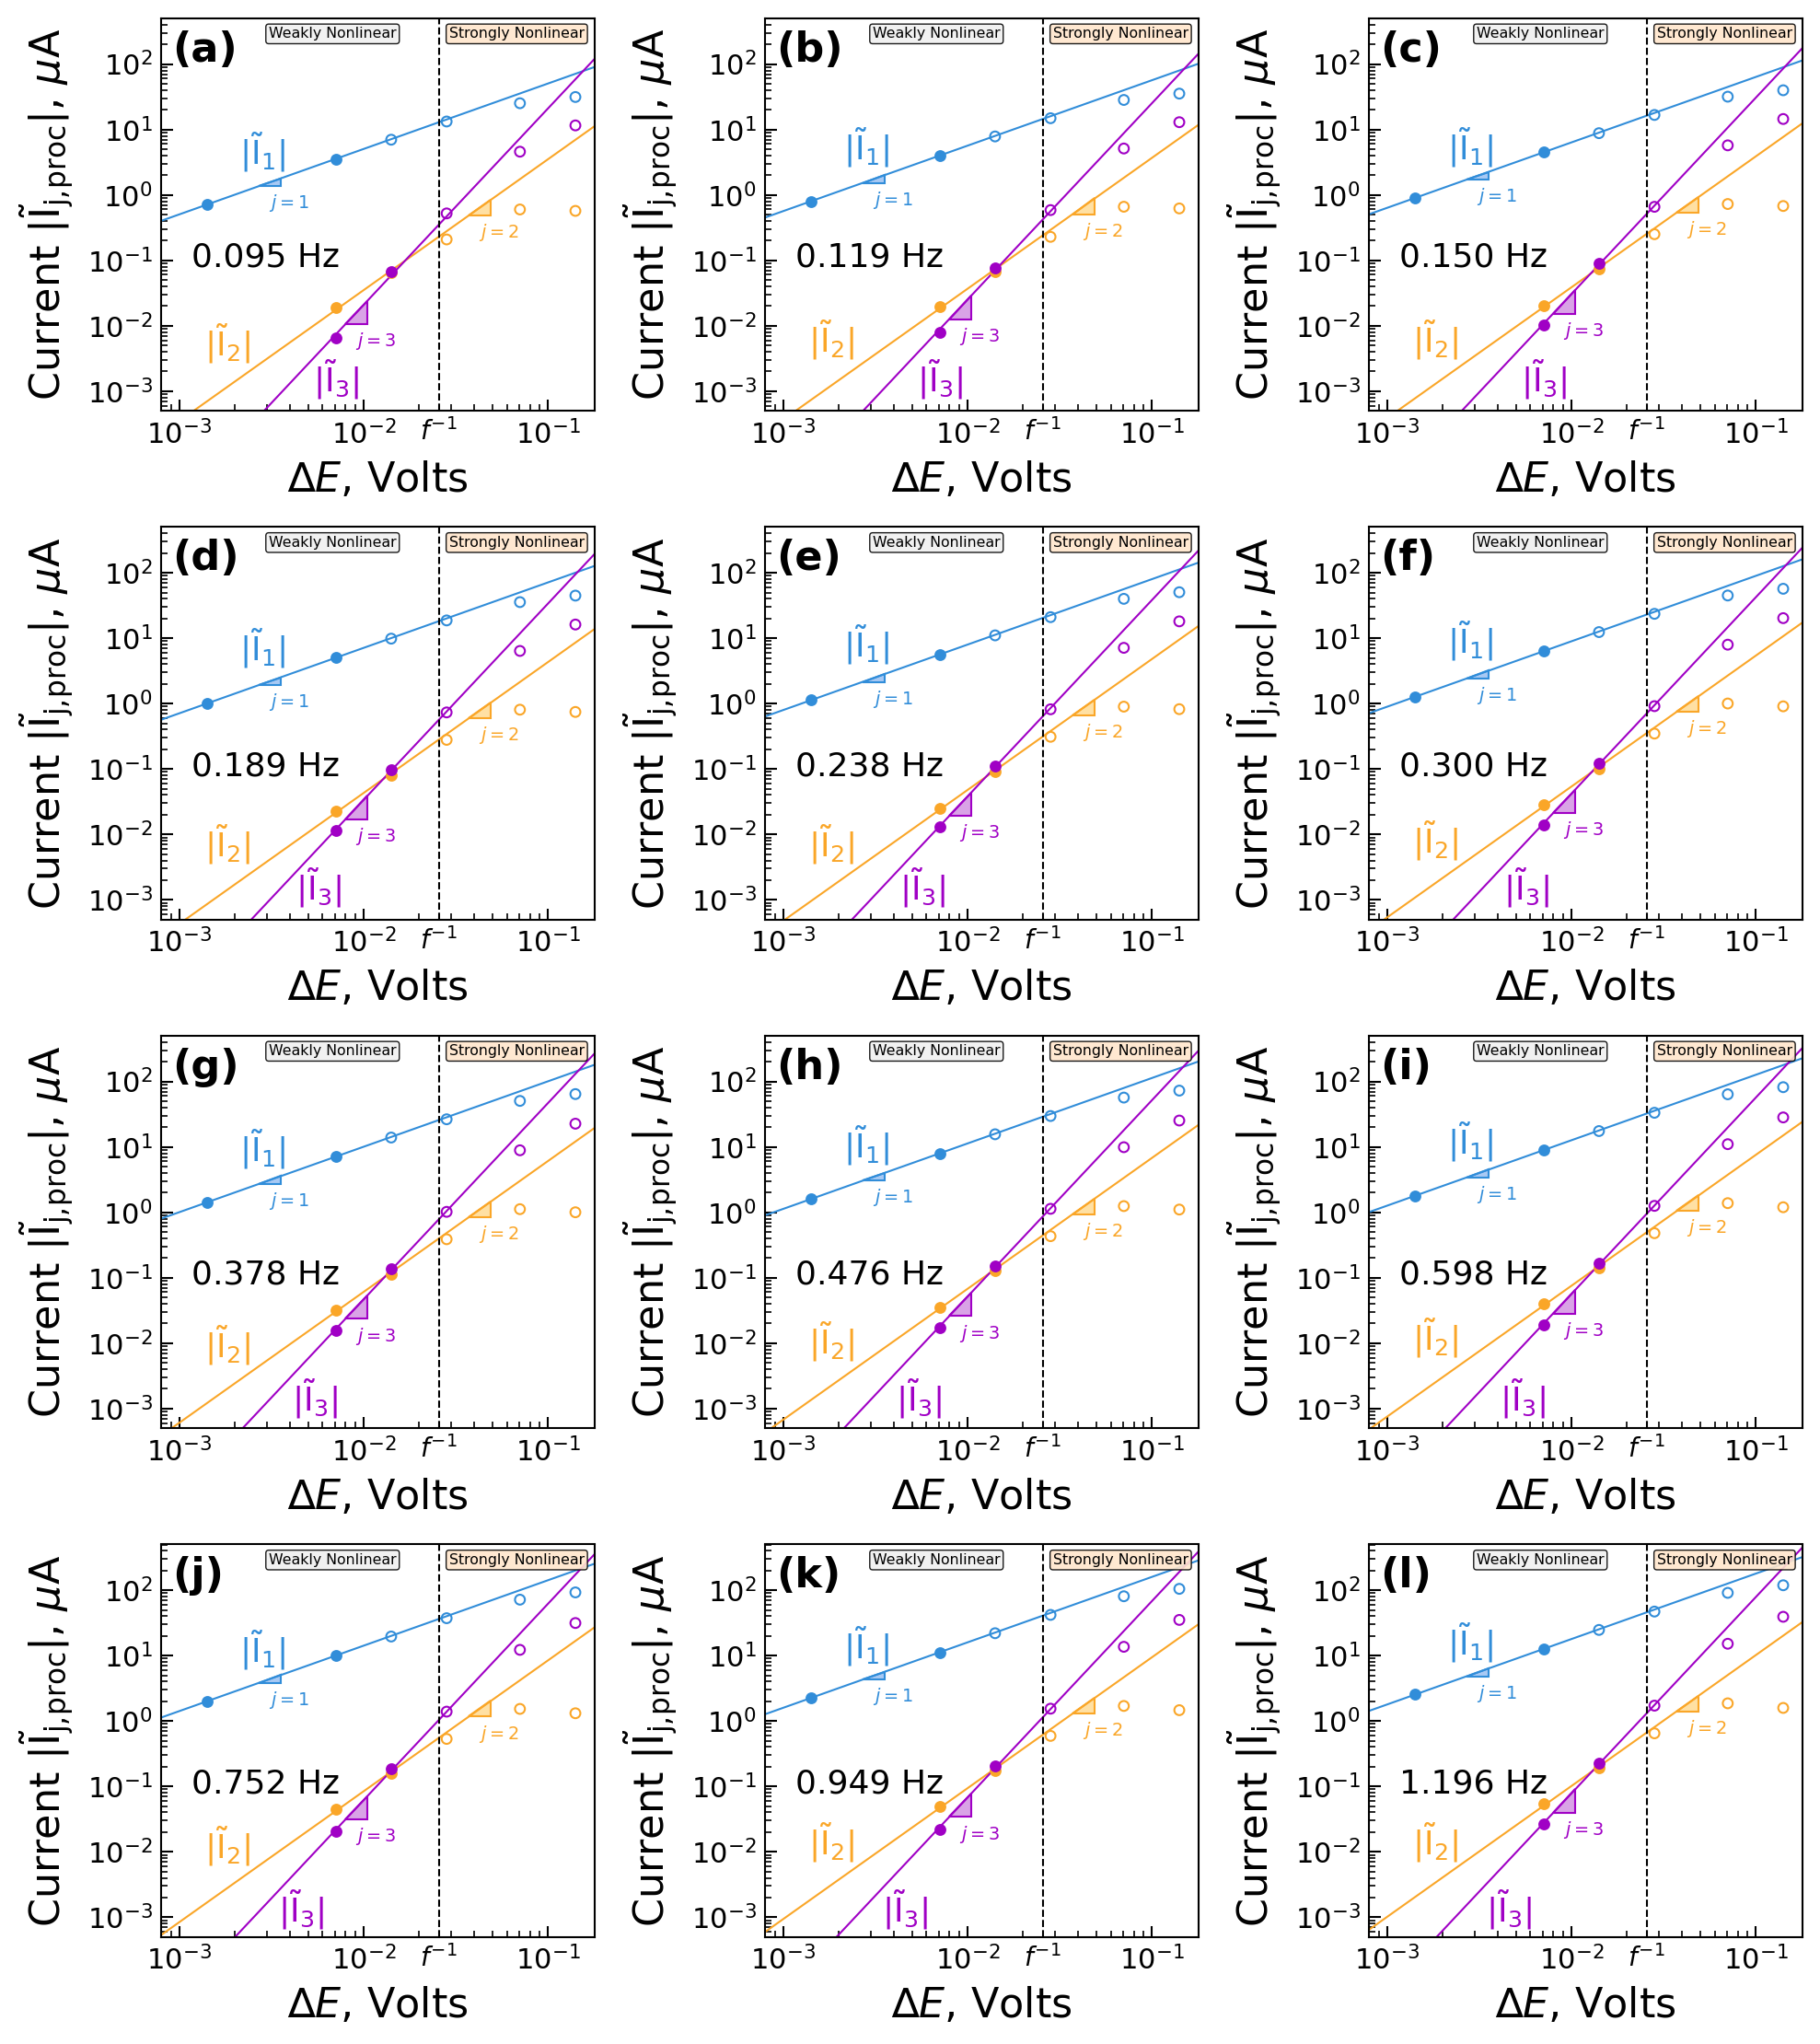

Run 2


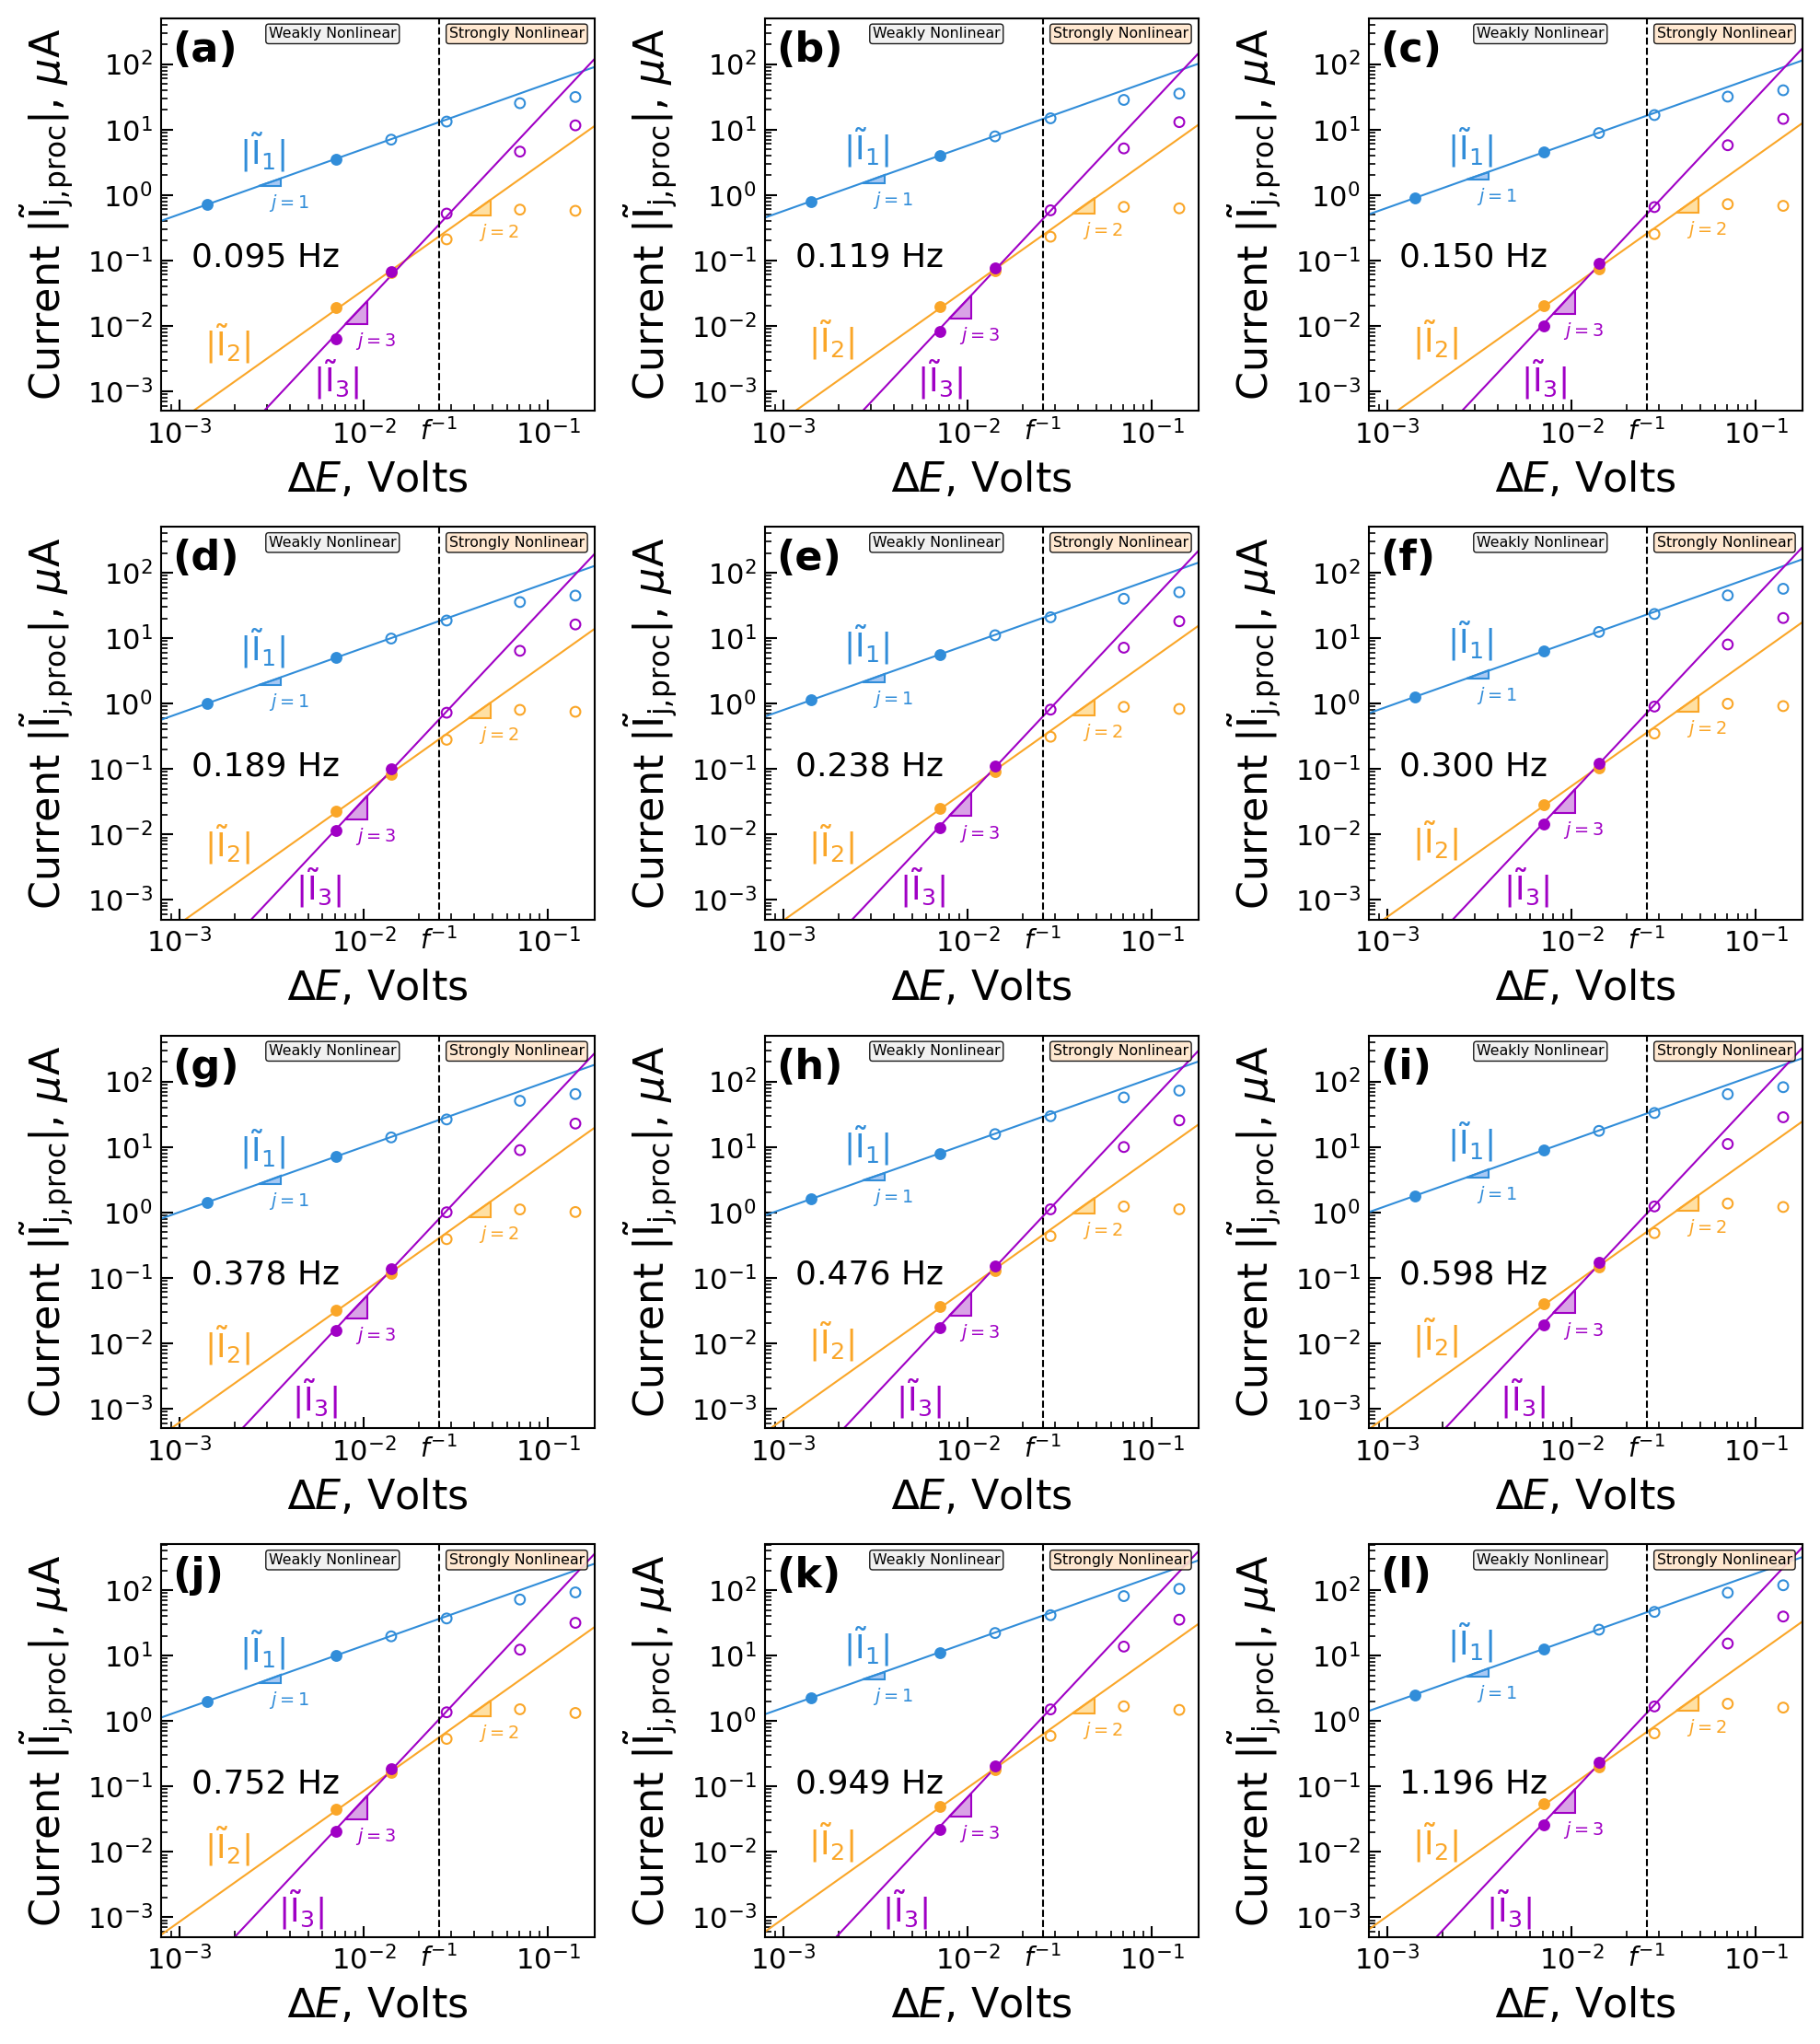

In [8]:
def make_grid(df_all, run, point_pairs_by_rank=None, num_currents=3):
    if point_pairs_by_rank is None:
        point_pairs_by_rank = {}

    # Match the standalone single-plot aspect ratio (3.33 x 2.8) per subplot.
    sub_w, sub_h = 3.33, 2.8
    n_rows, n_cols = 4, 3
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * sub_w, n_rows * sub_h), dpi=200)
    label_fontsize = 16
    subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)','(g)','(h)','(i)','(j)','(k)','(l)']
    count = 0
    
    # Order within each rank: (I1, I2, I3) — axes-fraction (x, y) positions
    harmonic_label_positions_by_rank = {
        1:  [(0.18, 0.66), (0.10, 0.17), (0.35, 0.08)],
        2:  [(0.18, 0.67), (0.10, 0.18), (0.35, 0.08)],
        3:  [(0.18, 0.67), (0.10, 0.18), (0.35, 0.08)],
        4:  [(0.18, 0.69), (0.10, 0.19), (0.31, 0.08)],
        5:  [(0.18, 0.7), (0.10, 0.19), (0.31, 0.08)],
        6:  [(0.18, 0.71), (0.10, 0.2), (0.31, 0.08)],
        7:  [(0.18, 0.71), (0.10, 0.21), (0.30, 0.075)],
        8:  [(0.18, 0.72), (0.10, 0.22), (0.30, 0.075)],
        9:  [(0.18, 0.73), (0.10, 0.23), (0.30, 0.075)],
        10: [(0.18, 0.73), (0.10, 0.23), (0.27, 0.07)],
        11: [(0.18, 0.74), (0.10, 0.24), (0.27, 0.07)],
        12: [(0.18, 0.75), (0.10, 0.24), (0.27, 0.07)],
    }

    harmonic_label_texts = [
        r'|$\tilde{\mathrm{I}}_{\mathrm{1}}$|',
        r'|$\tilde{\mathrm{I}}_{\mathrm{2}}$|',
        r'|$\tilde{\mathrm{I}}_{\mathrm{3}}$|',
    ]

    
    for rank in range(1, 13):
        positions = dict(zip(harmonic_label_texts,
                             harmonic_label_positions_by_rank[rank]))
        row = (rank - 1) // n_cols
        col = (rank - 1) % n_cols
        ax = axes[row, col]

        df_sub = df_all[(df_all["Rank"] == rank) &
                        (df_all["File Number"] == run)].sort_values("VHr1").reset_index(drop=True)
        pairs = point_pairs_by_rank.get(rank, [(1, 2), (2, 3), (2, 3)])

        plot_filled_pair(ax, df_sub, num_currents, pairs, run)
        ax.text(0.025, 0.97, subplot_labels[count], transform=ax.transAxes,
        fontsize=label_fontsize, fontweight='bold', va='top', ha='left')

        # Change Font Sizes for Grid
        for t in ax.texts:
            if t.get_text() in ("Weakly Nonlinear", "Strongly Nonlinear"):
                t.set_fontsize(5.7)
            if t.get_text() == "Weakly Nonlinear":
                x, y = t.get_position()
                t.set_position((x * 1.5, y))
            if t.get_text() in positions:
                t.set_position(positions[t.get_text()])
                t.set_fontsize(13)

        ax.xaxis.label.set_fontsize(16)
        ax.yaxis.label.set_fontsize(16)
        ax.tick_params(axis='both', which='major', labelsize=11)

        freq = df_sub["Freq"].iloc[0]
        ax.text(0.07, 0.43, f"{freq:.3f} Hz", transform=ax.transAxes,
                fontsize=13, color="black", ha='left', va='top')
        
        count += 1

    fig.tight_layout()
    if run == 1:
        fig_label = "S6"
    else:
        fig_label = "S7"
    fig.savefig(f"{fig_label}_Harmonic_Growth_All_Frequencies_Run{run}.pdf",
                bbox_inches='tight', pad_inches=0.05)
    plt.show()
    return

print("Run 1")
make_grid(df, run=1)
print("Run 2")
make_grid(df, run=2)